# 📚 Data Mining — Student Performance

**Alur Notebook:**
1. Import Library
2. Definisi Variabel Kolom (1 sel, dipanggil sepanjang notebook)
3. Load & Eksplorasi Data
4. Preprocessing (Cleaning, Encoding, Normalisasi, Binning)
5. PCA (Reduksi Dimensi)
6. Clustering (KMeans)
7. Klasifikasi (Naive Bayes + K-Fold Cross Validation)

## 0. Business Understanding

**Permasalahan:** Pihak akademik membutuhkan cara untuk memahami pola performa siswa berdasarkan faktor-faktor seperti jam belajar, kehadiran, nilai tugas, dan partisipasi, guna mendukung deteksi dini siswa yang berisiko mengalami performa akademik rendah.

**Tujuan Analisis:**
1. Mengelompokkan siswa berdasarkan karakteristik aktivitas dan pencapaian akademik (unsupervised learning — clustering).
2. Membangun model prediktif untuk mengklasifikasikan kategori performa siswa (Low/Medium/High) berdasarkan fitur-fitur akademik dan non-akademik (supervised learning — classification).
3. Menyampaikan insight hasil analisis dalam bentuk dashboard sederhana yang dapat digunakan pihak akademik untuk pengambilan keputusan.

**Kerangka Kerja:** Notebook ini disusun mengikuti metodologi **CRISP-DM (Cross-Industry Standard Process for Data Mining)**, dengan pemetaan sebagai berikut:

| Section Notebook | Fase CRISP-DM |
|---|---|
| 0. Business Understanding | Business Understanding |
| 3. Load & Eksplorasi Data | Data Understanding |
| 4. Preprocessing (Cleaning, Outlier Handling, Binning, Encoding, Normalisasi) | Data Preparation |
| 5. PCA & Diagnostik Cluster | Data Preparation / Modeling (persiapan) |
| 6. Clustering (KMeans) | Modeling (Unsupervised) |
| 7. Klasifikasi (Naive Bayes) | Modeling (Supervised) |
| 8. Klasifikasi (Logistic Regression) | Modeling (Supervised) |
| Silhouette, Davies-Bouldin, ARI/NMI, Accuracy, F1, ROC-AUC (tersebar di tiap section) | Evaluation |
| 9. Perbandingan Model | Evaluation / Interpretasi |
| 10. Dashboard (belum) | Deployment |

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score,
    accuracy_score, classification_report,
    confusion_matrix, roc_curve, auc
)
from sklearn.preprocessing import label_binarize


## 2. Definisi Variabel Kolom



In [2]:
# ── Kolom identitas 
ID_COL = 'student_id'

# ── Kolom numerik utama (untuk analisis & normalisasi)
NUM_COLS = [
    'study_hours_per_day',
    'attendance_percentage',
    'assignment_score',
    'midterm_score',
    'final_exam_score',
    'participation_score',
    'sleep_hours'
]

# ── Kolom fitur untuk clustering & PCA (tidak termasuk sleep_hours, lebih fokus ke akademik)
CLUSTER_COLS = [
    'study_hours_per_day',
    'attendance_percentage',
    'assignment_score',
    'midterm_score',
    'final_exam_score',
    'participation_score'
]

# ── Kolom kategorikal biner Yes/No → One-Hot Encoding
BINARY_COLS = ['gender', 'internet_access', 'extra_classes']

# ── Kolom kategorikal nominal multi-nilai → One-Hot Encoding
NOMINAL_COLS = ['parent_education']

# ── Kolom target klasifikasi
TARGET_COL = 'Performance_Category'

# ── Kolom yang tidak dipakai dalam model klasifikasi
DROP_FOR_MODEL = ['overall_score', 'grade', TARGET_COL]

print('Variabel kolom berhasil didefinisikan.')
print(f'  NUM_COLS     : {NUM_COLS}')
print(f'  CLUSTER_COLS : {CLUSTER_COLS}')
print(f'  BINARY_COLS  : {BINARY_COLS}')
print(f'  NOMINAL_COLS : {NOMINAL_COLS}')

Variabel kolom berhasil didefinisikan.
  NUM_COLS     : ['study_hours_per_day', 'attendance_percentage', 'assignment_score', 'midterm_score', 'final_exam_score', 'participation_score', 'sleep_hours']
  CLUSTER_COLS : ['study_hours_per_day', 'attendance_percentage', 'assignment_score', 'midterm_score', 'final_exam_score', 'participation_score']
  BINARY_COLS  : ['gender', 'internet_access', 'extra_classes']
  NOMINAL_COLS : ['parent_education']


## 3. Load & Eksplorasi Data

In [3]:
df_raw = pd.read_csv('student_performance_data.csv')
print('Shape:', df_raw.shape)
df_raw.head()

Shape: (10000, 14)


,student_id,gender,study_hours_per_day,attendance_percentage,assignment_score,midterm_score,final_exam_score,participation_score,internet_access,extra_classes,parent_education,sleep_hours,overall_score,grade
0,100000,Male,4.54,69.98,36.47,70.70,53.10,17.96,Yes,No,Master,8.09,52.3480,D
1,100001,Female,5.26,84.80,34.25,27.92,87.17,11.29,No,Yes,Bachelor,4.73,53.9485,D
2,100002,Male,8.69,73.76,72.29,70.92,99.61,76.10,No,Yes,PhD,8.73,82.0375,B
3,100003,Male,4.06,45.00,97.63,31.73,88.85,33.55,No,No,Bachelor,8.22,66.4110,C
4,100004,Male,8.83,51.13,65.19,78.28,54.23,88.99,No,No,Bachelor,8.59,65.6005,C


In [4]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             10000 non-null  int64  
 1   gender                 10000 non-null  str    
 2   study_hours_per_day    10000 non-null  float64
 3   attendance_percentage  10000 non-null  float64
 4   assignment_score       10000 non-null  float64
 5   midterm_score          10000 non-null  float64
 6   final_exam_score       10000 non-null  float64
 7   participation_score    10000 non-null  float64
 8   internet_access        10000 non-null  str    
 9   extra_classes          10000 non-null  str    
 10  parent_education       10000 non-null  str    
 11  sleep_hours            10000 non-null  float64
 12  overall_score          10000 non-null  float64
 13  grade                  10000 non-null  str    
dtypes: float64(8), int64(1), str(5)
memory usage: 1.2 MB


In [5]:
df_raw.describe()

,student_id,study_hours_per_day,attendance_percentage,assignment_score,midterm_score,final_exam_score,participation_score,sleep_hours,overall_score
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,104999.50000,5.467825,70.493817,64.717809,62.322568,64.979987,55.103202,6.505165,63.826901
std,2886.89568,2.594134,17.295607,20.052779,21.710555,20.216141,25.955949,1.458246,10.230977
min,100000.00000,1.000000,40.000000,30.000000,25.000000,30.010000,10.000000,4.000000,33.263500
25%,102499.75000,3.220000,55.640000,47.320000,43.515000,47.400000,32.955000,5.220000,56.528125
50%,104999.50000,5.420000,70.780000,64.770000,62.050000,65.210000,55.055000,6.520000,63.780750
75%,107499.25000,7.740000,85.200000,81.760000,81.227500,82.500000,77.760000,7.792500,71.163125
max,109999.00000,10.000000,100.000000,99.990000,100.000000,100.000000,99.990000,9.000000,96.879500


### Visualisasi Distribusi Data

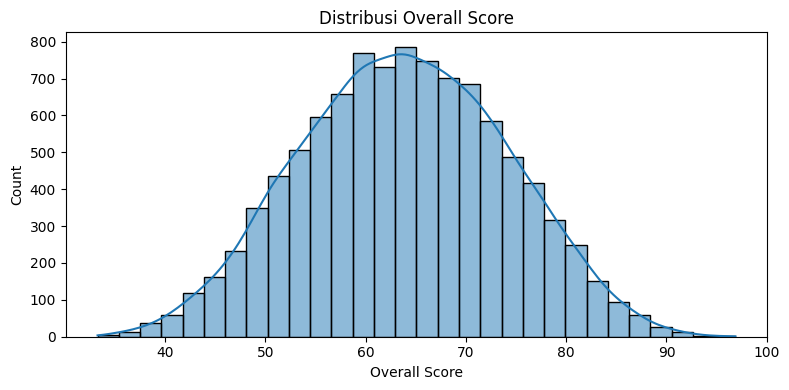

In [6]:
plt.figure(figsize=(8, 4))
sns.histplot(df_raw['overall_score'], bins=30, kde=True)
plt.title('Distribusi Overall Score')
plt.xlabel('Overall Score')
plt.tight_layout()
plt.show()

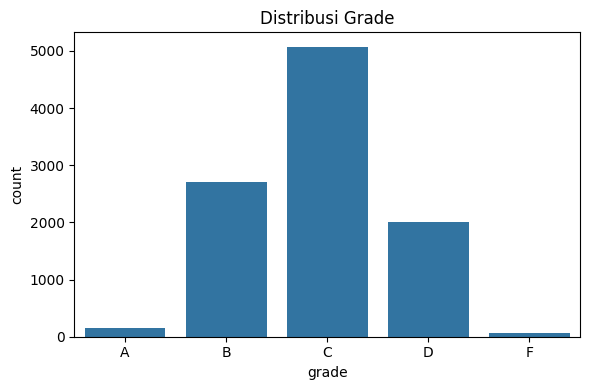

In [7]:
plt.figure(figsize=(6, 4))
order = sorted(df_raw['grade'].unique())
sns.countplot(data=df_raw, x='grade', order=order)
plt.title('Distribusi Grade')
plt.tight_layout()
plt.show()

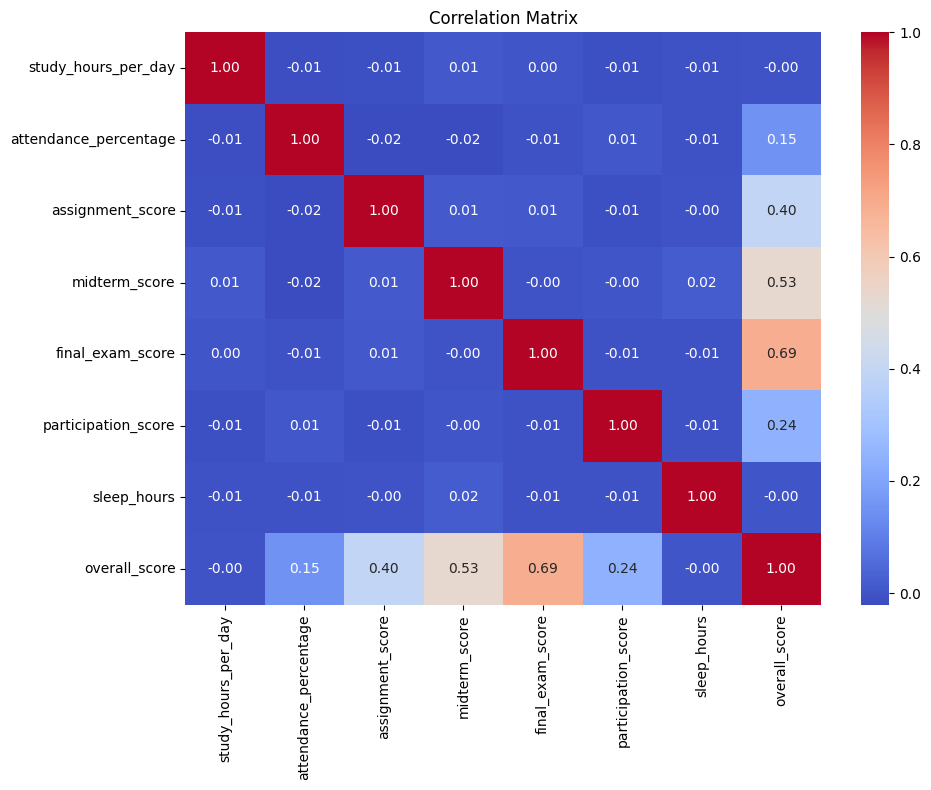

In [8]:
plt.figure(figsize=(10, 8))
corr = df_raw[NUM_COLS + ['overall_score']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

## 4. Preprocessing

### 4.1 Data Cleaning

In [9]:
# drop kolom ID
df = df_raw.drop(columns=[ID_COL])

# Cek missing value & duplikasi
print('Missing values:')
print(df.isnull().sum())
print()
print('Jumlah duplikasi:', df.duplicated().sum())
print('Shape setelah drop ID:', df.shape)

Missing values:
gender                   0
study_hours_per_day      0
attendance_percentage    0
assignment_score         0
midterm_score            0
final_exam_score         0
participation_score      0
internet_access          0
extra_classes            0
parent_education         0
sleep_hours              0
overall_score            0
grade                    0
dtype: int64

Jumlah duplikasi: 0
Shape setelah drop ID: (10000, 13)


### 4.2 Outlier Handling

Outlier ditangani menggunakan metode **IQR (Interquartile Range)** pada kolom numerik. Data yang berada di luar batas `Q1 - 1.5*IQR` dan `Q3 + 1.5*IQR` dianggap outlier dan dihapus.

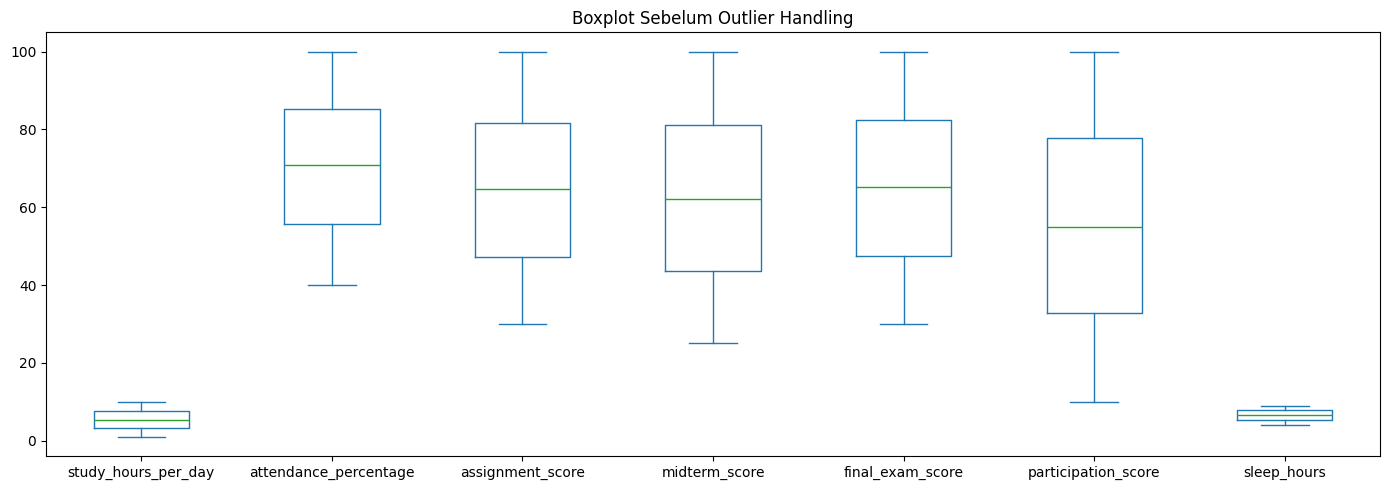

In [10]:
# Boxplot sebelum cleaning outliner
df[NUM_COLS].plot(kind='box', figsize=(14, 5), title='Boxplot Sebelum Outlier Handling')
plt.tight_layout()
plt.show()

In [11]:
df_clean = df.copy()

for col in NUM_COLS:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

print(f'Data sebelum  : {len(df)} baris')
print(f'Data sesudah  : {len(df_clean)} baris')
print(f'Data dihapus  : {len(df) - len(df_clean)} baris')

Data sebelum  : 10000 baris
Data sesudah  : 10000 baris
Data dihapus  : 0 baris


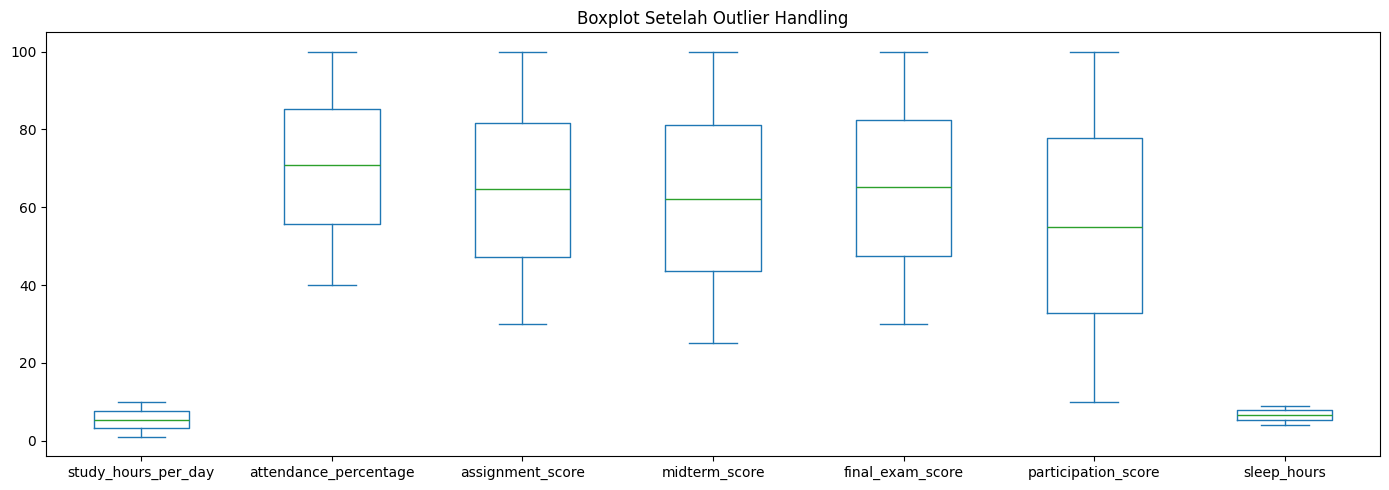

In [12]:
# Boxplot setelah cleaning outlier
df_clean[NUM_COLS].plot(kind='box', figsize=(14, 5), title='Boxplot Setelah Outlier Handling')
plt.tight_layout()
plt.show()

df = df_clean.reset_index(drop=True)

### 4.3 Binning — Membuat Performance Category

**Alasan pemilihan batas kategori:**
Kategori `Low`, `Medium`, `High` dibuat berdasarkan **quantile 33% dan 66%** dari `overall_score`. Cara ini lebih adil dibanding `bins=3` (yang membagi range secara merata) karena distribusi data bisa tidak merata. Dengan quantile, tiap kelas memiliki jumlah data yang **seimbang**.

- **Low** : overall_score ≤ Q33
- **Medium** : Q33 < overall_score ≤ Q66
- **High** : overall_score > Q66

Kolom ini menggunakan **Label Encoding (0=Low, 1=Medium, 2=High)** karena kategorinya **ordinal** (ada urutan). One-Hot Encoding tidak tepat untuk data ordinal karena menghilangkan informasi urutan.

In [13]:
q33 = df['overall_score'].quantile(0.33)
q66 = df['overall_score'].quantile(0.66)

print(f'Batas Low  : overall_score ≤ {q33:.2f}')
print(f'Batas Med  : {q33:.2f} < overall_score ≤ {q66:.2f}')
print(f'Batas High : overall_score > {q66:.2f}')

# Label Encoding: 0=Low, 1=Medium, 2=High
df[TARGET_COL] = pd.cut(
    df['overall_score'],
    bins=[-np.inf, q33, q66, np.inf],
    labels=[0, 1, 2]
).astype(int)

print()
print('Distribusi Performance Category (0=Low, 1=Medium, 2=High):')
print(df[TARGET_COL].value_counts().sort_index())

Batas Low  : overall_score ≤ 59.05
Batas Med  : 59.05 < overall_score ≤ 68.31
Batas High : overall_score > 68.31

Distribusi Performance Category (0=Low, 1=Medium, 2=High):
Performance_Category
0    3300
1    3300
2    3400
Name: count, dtype: int64


### 4.4 Encoding Variabel Kategorikal

**Strategi encoding:**
- `gender`, `internet_access`, `extra_classes` → **One-Hot Encoding** karena biner (Yes/No, Male/Female) dan **nominal** (tidak ada urutan)
- `parent_education` → **One-Hot Encoding** karena nominal dengan >2 nilai
- `Performance_Category` → sudah **Label Encoded** (0/1/2) di langkah sebelumnya
- `grade` → tidak dipakai sebagai fitur (hanya sebagai referensi)

Semua encoding dilakukan **dalam 1 langkah** menggunakan `pd.get_dummies`.

In [14]:
# One-Hot Encoding untuk semua kolom kategorikal nominal sekaligus
df_encoded = pd.get_dummies(
    df,
    columns=BINARY_COLS + NOMINAL_COLS,
    drop_first=False 
)

print('Kolom setelah encoding:')
print(df_encoded.columns.tolist())
print()
print('Shape:', df_encoded.shape)
df_encoded.head()

Kolom setelah encoding:
['study_hours_per_day', 'attendance_percentage', 'assignment_score', 'midterm_score', 'final_exam_score', 'participation_score', 'sleep_hours', 'overall_score', 'grade', 'Performance_Category', 'gender_Female', 'gender_Male', 'internet_access_No', 'internet_access_Yes', 'extra_classes_No', 'extra_classes_Yes', 'parent_education_Bachelor', 'parent_education_High School', 'parent_education_Master', 'parent_education_PhD']

Shape: (10000, 20)


,study_hours_per_day,attendance_percentage,assignment_score,midterm_score,final_exam_score,participation_score,sleep_hours,overall_score,grade,Performance_Category,gender_Female,gender_Male,internet_access_No,internet_access_Yes,extra_classes_No,extra_classes_Yes,parent_education_Bachelor,parent_education_High School,parent_education_Master,parent_education_PhD
0,4.54,69.98,36.47,70.70,53.10,17.96,8.09,52.3480,D,0,False,True,False,True,True,False,False,False,True,False
1,5.26,84.80,34.25,27.92,87.17,11.29,4.73,53.9485,D,0,True,False,True,False,False,True,True,False,False,False
2,8.69,73.76,72.29,70.92,99.61,76.10,8.73,82.0375,B,2,False,True,True,False,False,True,False,False,False,True
3,4.06,45.00,97.63,31.73,88.85,33.55,8.22,66.4110,C,1,False,True,True,False,True,False,True,False,False,False
4,8.83,51.13,65.19,78.28,54.23,88.99,8.59,65.6005,C,1,False,True,True,False,True,False,True,False,False,False


### 4.5 Normalisasi — MinMaxScaler

**Alasan menggunakan MinMaxScaler:**
- Fitur numerik memiliki skala berbeda (jam belajar: 1–10, skor: 0–100)
- MinMaxScaler menyeragamkan semua fitur ke rentang **[0, 1]** tanpa mengasumsikan distribusi normal
- Cocok untuk algoritma yang sensitif terhadap skala seperti **KMeans clustering**
- StandardScaler lebih cocok digunakan khusus untuk **PCA** (dilakukan terpisah di bagian PCA)

> ⚠️ **Scaler hanya di-fit sekali di sini** dan digunakan kembali. Tidak diulang di bagian lain.

In [15]:
mm_scaler = MinMaxScaler()
df_encoded[NUM_COLS] = mm_scaler.fit_transform(df_encoded[NUM_COLS])

print('Hasil normalisasi:')
df_encoded[NUM_COLS].head()

Hasil normalisasi:


,study_hours_per_day,attendance_percentage,assignment_score,midterm_score,final_exam_score,participation_score,sleep_hours
0,0.393333,0.499667,0.092442,0.609333,0.329904,0.088454,0.818
1,0.473333,0.746667,0.060723,0.038933,0.816688,0.014335,0.146
2,0.854444,0.562667,0.604229,0.612267,0.994428,0.734526,0.946
3,0.340000,0.083333,0.966281,0.089733,0.840692,0.261696,0.844
4,0.870000,0.185500,0.502786,0.710400,0.346049,0.877764,0.918


## 5. PCA — Reduksi Dimensi

PCA dilakukan menggunakan **StandardScaler** (bukan MinMaxScaler) karena PCA sensitif terhadap varians, dan StandardScaler mempertahankan proporsi varians lebih baik.

> **Penting:** StandardScaler di sini **hanya dipakai untuk PCA**, bukan untuk preprocessing model. Ini adalah scaler yang berbeda dari MinMaxScaler di atas.

In [16]:
# Ambil fitur clustering untuk PCA
X_cluster = df[CLUSTER_COLS].copy()

# StandardScaler khusus untuk PCA (fit sekali)
std_scaler = StandardScaler()
X_std = std_scaler.fit_transform(X_cluster)

print('Data sudah di-standardize untuk PCA.')

Data sudah di-standardize untuk PCA.


Explained Variance per Komponen:
  PC1: 0.1737 (17.4%)  |  Kumulatif: 17.4%
  PC2: 0.1689 (16.9%)  |  Kumulatif: 34.3%
  PC3: 0.1680 (16.8%)  |  Kumulatif: 51.1%
  PC4: 0.1652 (16.5%)  |  Kumulatif: 67.6%
  PC5: 0.1629 (16.3%)  |  Kumulatif: 83.9%
  PC6: 0.1613 (16.1%)  |  Kumulatif: 100.0%


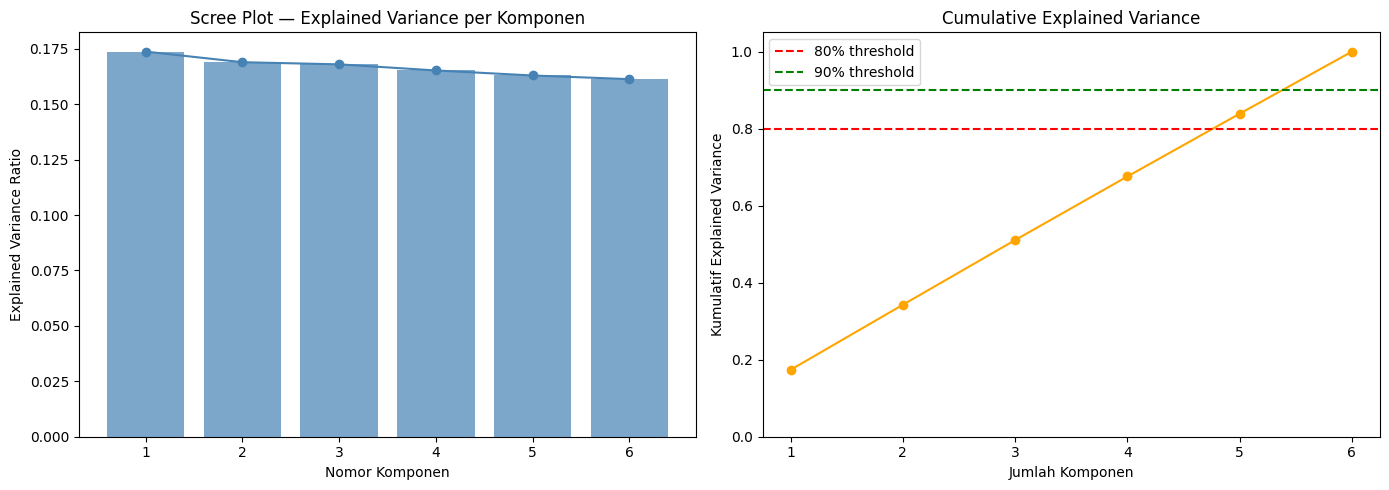

In [17]:
# Fit PCA dengan semua komponen untuk melihat explained variance
pca_full = PCA()
pca_full.fit(X_std)

evr = pca_full.explained_variance_ratio_
cumulative_evr = np.cumsum(evr)

print('Explained Variance per Komponen:')
for i, (ev, cum) in enumerate(zip(evr, cumulative_evr), 1):
    print(f'  PC{i}: {ev:.4f} ({ev*100:.1f}%)  |  Kumulatif: {cum*100:.1f}%')

# Scree Plot — membantu memilih jumlah komponen
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, len(evr)+1), evr, alpha=0.7, color='steelblue', label='Per komponen')
axes[0].plot(range(1, len(evr)+1), evr, 'o-', color='steelblue')
axes[0].set_xlabel('Nomor Komponen')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot — Explained Variance per Komponen')
axes[0].set_xticks(range(1, len(evr)+1))

# Cumulative explained variance
axes[1].plot(range(1, len(cumulative_evr)+1), cumulative_evr, 'o-', color='orange')
axes[1].axhline(y=0.80, color='red', linestyle='--', label='80% threshold')
axes[1].axhline(y=0.90, color='green', linestyle='--', label='90% threshold')
axes[1].set_xlabel('Jumlah Komponen')
axes[1].set_ylabel('Kumulatif Explained Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xticks(range(1, len(cumulative_evr)+1))
axes[1].legend()
axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

**Interpretasi Scree Plot:**

Pada dataset ini, setiap fitur menyumbang varians yang hampir merata (sekitar 14–15% per komponen). Ini menunjukkan bahwa **keenam fitur sudah cukup independen** dan tidak ada satu komponen dominan.

Untuk visualisasi clustering, kita tetap proyeksikan ke **2 komponen (PC1 & PC2)** meskipun total variance yang dijelaskan sekitar 29%. Ini adalah trade-off untuk keperluan **visualisasi 2D**. Untuk model, kita tetap menggunakan fitur asli.

In [18]:
# Proyeksi PCA ke 2 komponen untuk visualisasi
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_std)

df_pca = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'])

print(f'PC1 explains: {pca_2d.explained_variance_ratio_[0]*100:.1f}%')
print(f'PC2 explains: {pca_2d.explained_variance_ratio_[1]*100:.1f}%')
print(f'Total       : {sum(pca_2d.explained_variance_ratio_)*100:.1f}%')

PC1 explains: 17.4%
PC2 explains: 16.9%
Total       : 34.3%


### 5.x Diagnostik Awal — Apakah Data Punya Struktur Cluster?

Sebelum menjalankan KMeans, kita cek dulu secara visual apakah fitur-fitur clustering memang punya kecenderungan membentuk kelompok (blob terpisah) atau tidak. Ini penting karena KMeans akan **selalu** menghasilkan k cluster berapapun strukturnya — jadi perlu dicek dulu apakah hasilnya nanti bermakna atau tidak.

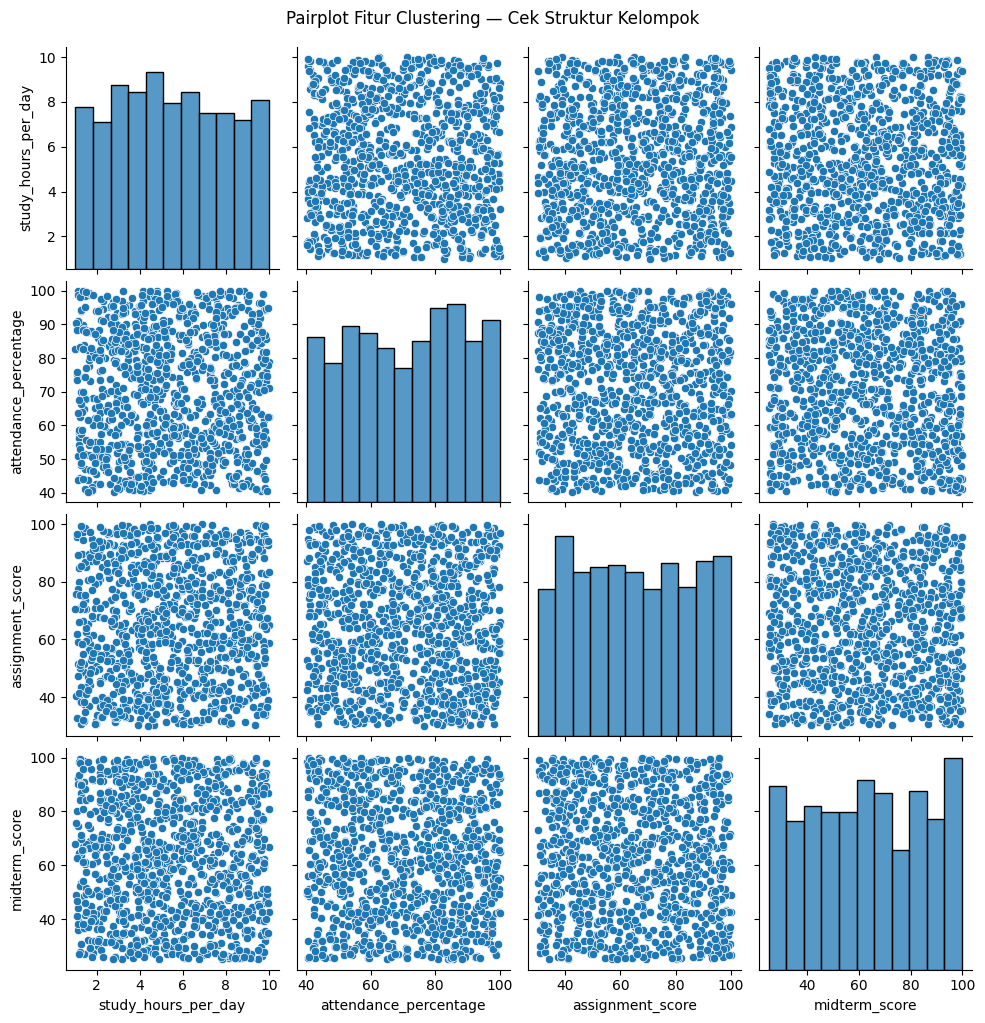

In [19]:
# Pairplot fitur-fitur clustering utama (sample 1000 baris agar tidak terlalu berat)
sns.pairplot(df[CLUSTER_COLS[:4]].sample(1000, random_state=42))
plt.suptitle('Pairplot Fitur Clustering — Cek Struktur Kelompok', y=1.02)
plt.show()

**Interpretasi Pairplot:**

Scatter plot di luar diagonal menunjukkan titik-titik yang menyebar rata (uniform) mengisi seluruh area, tanpa ada celah kosong atau gumpalan (blob) yang terpisah. Histogram pada diagonal juga relatif rata (tidak ada beberapa puncak/multi-modal). Ini adalah indikasi awal bahwa **fitur-fitur akademik tidak memiliki struktur kelompok alami** — kemungkinan besar karena fitur-fiturnya independen satu sama lain (lihat kembali heatmap korelasi di Bagian 3).

Kita tetap lanjutkan proses clustering sebagai bagian dari eksplorasi data mining yang lengkap, namun ekspektasi terhadap hasilnya perlu disesuaikan — silhouette score yang rendah nantinya bukan kegagalan implementasi, melainkan refleksi dari karakteristik data.

## 6. Clustering — KMeans

**Strategi:** Coba KMeans terlebih dahulu. Jika hasil sudah baik (silhouette score memadai, visualisasi menunjukkan titik terpisah), baru pertimbangkan metode lain.

### 6.1 Elbow Method — Menentukan k Optimal

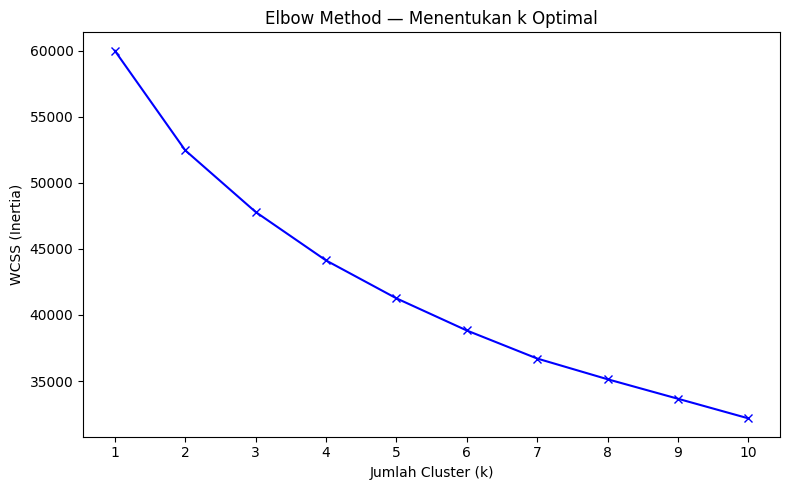

In [20]:
wcss = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_std)
    wcss.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, 'bx-')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method — Menentukan k Optimal')
plt.xticks(K_range)
plt.tight_layout()
plt.show()

### 6.2 Silhouette Score per k

In [21]:
sil_scores = {}

for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_std)
    sil = silhouette_score(X_std, labels_k)
    db  = davies_bouldin_score(X_std, labels_k)
    sil_scores[k] = sil
    print(f'k = {k}  ->  Silhouette: {sil:.4f}  |  Davies-Bouldin: {db:.4f}')

best_k = max(sil_scores, key=sil_scores.get)
print(f'\nk optimal berdasarkan Silhouette Score: {best_k}')

k = 2  ->  Silhouette: 0.1244  |  Davies-Bouldin: 2.5844
k = 3  ->  Silhouette: 0.1121  |  Davies-Bouldin: 2.2464
k = 4  ->  Silhouette: 0.1168  |  Davies-Bouldin: 2.1301
k = 5  ->  Silhouette: 0.1191  |  Davies-Bouldin: 1.8929
k = 6  ->  Silhouette: 0.1222  |  Davies-Bouldin: 1.7653
k = 7  ->  Silhouette: 0.1251  |  Davies-Bouldin: 1.6766

k optimal berdasarkan Silhouette Score: 7


**Catatan Silhouette Score:**
Silhouette score yang relatif rendah pada dataset ini wajar karena fitur-fitur akademik (skor, kehadiran) cenderung terdistribusi **kontinu dan tumpang tindih** — tidak ada pemisahan alami yang tajam antar kelompok. Nilai terbaik tetap dipilih dan digunakan untuk analisis lebih lanjut.

### 6.3 Training KMeans dengan k Optimal

In [22]:
k_optimal = best_k

kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_std)

df['Cluster_KMeans'] = kmeans_labels
df_encoded['Cluster_KMeans'] = kmeans_labels

print(f'Jumlah anggota tiap cluster (k={k_optimal}):')
print(pd.Series(kmeans_labels).value_counts().sort_index())

sil_final = silhouette_score(X_std, kmeans_labels)
db_final  = davies_bouldin_score(X_std, kmeans_labels)
print(f'\nSilhouette Score : {sil_final:.4f}  (mendekati 1 = lebih baik)')
print(f'Davies-Bouldin   : {db_final:.4f}  (mendekati 0 = lebih baik)')

Jumlah anggota tiap cluster (k=7):
0    1386
1    1481
2    1378
3    1288
4    1556
5    1522
6    1389
Name: count, dtype: int64

Silhouette Score : 0.1251  (mendekati 1 = lebih baik)
Davies-Bouldin   : 1.6766  (mendekati 0 = lebih baik)


### 6.4 Visualisasi Hasil Clustering (Proyeksi PCA 2D)

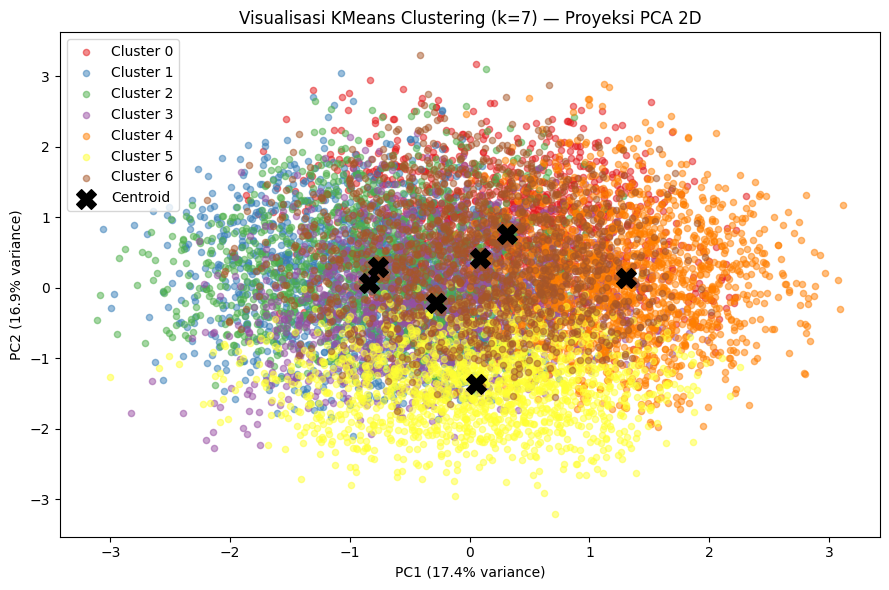

In [23]:
# Proyeksikan label cluster ke ruang PCA 2D
df_pca['Cluster'] = kmeans_labels

plt.figure(figsize=(9, 6))
colors = sns.color_palette('Set1', n_colors=k_optimal)

for i in range(k_optimal):
    mask = df_pca['Cluster'] == i
    plt.scatter(
        df_pca.loc[mask, 'PC1'],
        df_pca.loc[mask, 'PC2'],
        s=20, alpha=0.5, color=colors[i], label=f'Cluster {i}'
    )

# Plot centroid di ruang PCA
centroids_pca = pca_2d.transform(kmeans.cluster_centers_)
plt.scatter(
    centroids_pca[:, 0], centroids_pca[:, 1],
    s=200, c='black', marker='X', label='Centroid', zorder=5
)

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title(f'Visualisasi KMeans Clustering (k={k_optimal}) — Proyeksi PCA 2D')
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
# Profil rata-rata tiap cluster
cluster_profile = df.groupby('Cluster_KMeans')[CLUSTER_COLS].mean()
print('Rata-rata fitur per cluster:')
cluster_profile

Rata-rata fitur per cluster:


,study_hours_per_day,attendance_percentage,assignment_score,midterm_score,final_exam_score,participation_score
Cluster_KMeans,,,,,,
0,6.501429,83.929343,51.558658,69.845635,52.304582,34.688788
1,5.171499,55.917839,79.501540,68.130621,45.722708,47.999507
2,7.925740,70.896858,76.861655,76.847308,76.889013,69.520617
3,3.364511,63.604449,53.867710,81.558408,79.543711,57.389107
4,4.453400,83.214569,60.258946,52.227063,53.051073,80.887307
5,4.239126,77.292339,80.163679,47.400381,78.850861,39.946932
6,6.747070,56.917617,48.169186,44.036479,71.005436,54.348186


### 6.5 Evaluasi Tambahan — Apakah Cluster Sejalan dengan Performance_Category?

Untuk memperkuat analisis, kita bandingkan hasil cluster KMeans dengan label `Performance_Category` (Low/Medium/High) yang sudah didefinisikan dari `overall_score`. Jika cluster benar-benar bermakna terhadap performa siswa, seharusnya ada kesesuaian (meski tidak harus sempurna, karena keduanya dibentuk dengan cara berbeda).

In [25]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari = adjusted_rand_score(df['Performance_Category'], df['Cluster_KMeans'])
nmi = normalized_mutual_info_score(df['Performance_Category'], df['Cluster_KMeans'])

print(f'Adjusted Rand Index (ARI) : {ari:.4f}')
print(f'Normalized Mutual Info (NMI): {nmi:.4f}')
print()
print('Catatan: nilai mendekati 1 = cluster sangat sejalan dengan Performance_Category,')
print('nilai mendekati 0 = cluster tidak berkaitan dengan kategori performa asli.')

Adjusted Rand Index (ARI) : 0.1011
Normalized Mutual Info (NMI): 0.1509

Catatan: nilai mendekati 1 = cluster sangat sejalan dengan Performance_Category,
nilai mendekati 0 = cluster tidak berkaitan dengan kategori performa asli.


**Interpretasi ARI & NMI:**

Nilai ARI dan NMI yang mendekati 0 menunjukkan bahwa kelompok yang ditemukan KMeans **tidak sejalan** dengan kategori performa siswa (Low/Medium/High). Ini memperkuat temuan dari pairplot dan silhouette score sebelumnya: clustering pada fitur akademik mentah tidak menangkap pola yang relevan dengan performa keseluruhan siswa.

**Kesimpulan sementara untuk bagian Clustering:** KMeans tetap dijalankan sesuai prosedur data mining standar (Elbow Method, Silhouette Score, Davies-Bouldin Index), namun secara substantif hasil cluster pada dataset ini **tidak menghasilkan segmentasi yang bermakna**. Hal ini disebabkan oleh independensi antar fitur akademik (korelasi mendekati 0), yang membuat data tersebar uniform di ruang fitur tanpa membentuk kelompok alami. Bagian klasifikasi (Naive Bayes & Logistic Regression) jauh lebih sesuai untuk dataset ini karena target sudah terdefinisi jelas dari `overall_score`.

## 7. Klasifikasi — Gaussian Naive Bayes

**Target:** `Performance_Category` (0=Low, 1=Medium, 2=High)

**Alasan pemilihan Naive Bayes:**
- Cocok untuk klasifikasi multi-kelas
- Cepat, tidak membutuhkan banyak data
- Asumsi independensi antar fitur cukup terpenuhi pada dataset ini

**Evaluasi:** Menggunakan **K-Fold Cross Validation (k=5)** untuk menghindari overfitting dan memastikan model bekerja baik pada data yang belum dilihat.

### 7.1 Persiapan Fitur dan Target

In [26]:
# Pastikan df_encoded sudah tidak memiliki kolom yang tidak diperlukan
drop_for_model = [col for col in DROP_FOR_MODEL + ['grade'] if col in df_encoded.columns]

X_model = df_encoded.drop(columns=drop_for_model)
y_model = df_encoded[TARGET_COL]

# Jika ada kolom bool (dari get_dummies), ubah ke int
X_model = X_model.astype({col: int for col in X_model.select_dtypes(include='bool').columns})

print("Shape X_model:", X_model.shape)
print("Distribusi target:")
print(y_model.value_counts().sort_index())

Shape X_model: (10000, 18)
Distribusi target:
Performance_Category
0    3300
1    3300
2    3400
Name: count, dtype: int64


### 7.2 K-Fold Cross Validation (k=5)

K-Fold digunakan **sebagai pengganti train-test split biasa** agar:
- Model diuji pada semua data (tidak hanya 20% tertentu)
- Menghindari overfitting (model tidak menghapal data tertentu)
- Estimasi performa lebih stabil dan reliable

In [27]:
nb_model = GaussianNB()

# StratifiedKFold memastikan proporsi kelas terjaga di setiap fold
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    nb_model, X_model, y_model,
    cv=kf, scoring='accuracy'
)

print('Accuracy per fold:')
for i, score in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {score:.4f} ({score*100:.1f}%)')

print(f'\nMean Accuracy : {cv_scores.mean():.4f} ({cv_scores.mean()*100:.1f}%)')
print(f'Std Accuracy  : {cv_scores.std():.4f}')

if cv_scores.mean() >= 0.70:
    print('\n✅ Akurasi ≥ 70% — Model cukup baik!')
else:
    print('\n⚠️ Akurasi < 70% — Perlu evaluasi ulang preprocessing atau fitur.')

Accuracy per fold:
  Fold 1: 0.8345 (83.5%)
  Fold 2: 0.8485 (84.9%)
  Fold 3: 0.8545 (85.5%)
  Fold 4: 0.8460 (84.6%)
  Fold 5: 0.8540 (85.4%)

Mean Accuracy : 0.8475 (84.7%)
Std Accuracy  : 0.0073

✅ Akurasi ≥ 70% — Model cukup baik!


### 7.3 Evaluasi Detail — Classification Report & Confusion Matrix

In [28]:
# Prediksi menggunakan cross_val_predict (tidak ada data leakage)
y_pred_cv = cross_val_predict(nb_model, X_model, y_model, cv=kf)

print('Classification Report (Cross-Validated):')
print(classification_report(
    y_model, y_pred_cv,
    target_names=['Low (0)', 'Medium (1)', 'High (2)']
))

Classification Report (Cross-Validated):
              precision    recall  f1-score   support

     Low (0)       0.92      0.86      0.89      3300
  Medium (1)       0.73      0.85      0.79      3300
    High (2)       0.92      0.83      0.87      3400

    accuracy                           0.85     10000
   macro avg       0.86      0.85      0.85     10000
weighted avg       0.86      0.85      0.85     10000



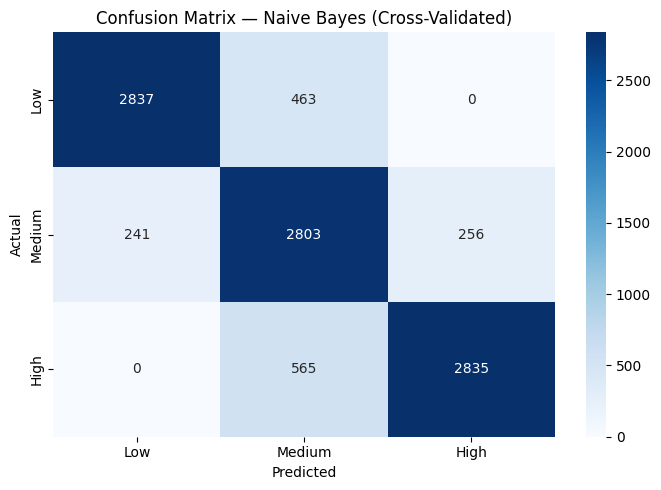

In [29]:
# Confusion Matrix
cm = confusion_matrix(y_model, y_pred_cv)
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Low', 'Medium', 'High'],
    yticklabels=['Low', 'Medium', 'High']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Naive Bayes (Cross-Validated)')
plt.tight_layout()
plt.show()

### 7.4 ROC AUC Curve

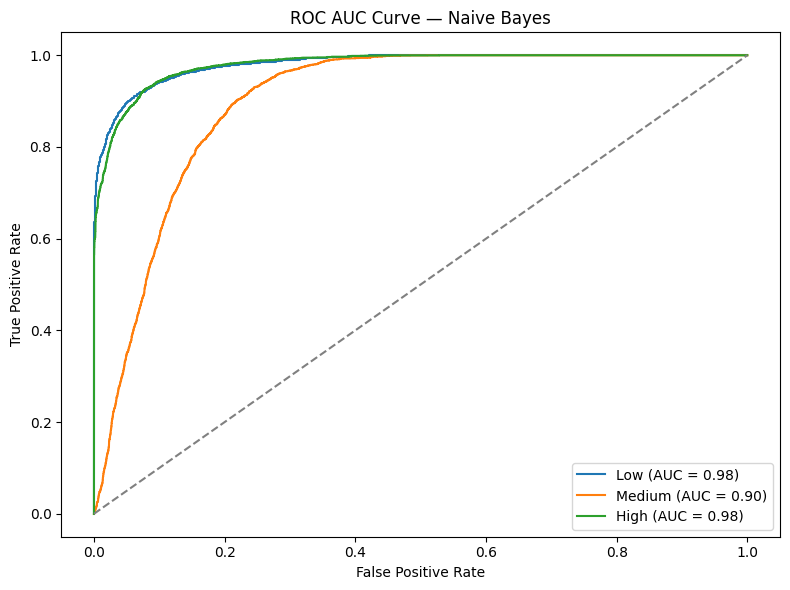

In [30]:
# Gunakan cross_val_predict dengan method='predict_proba' agar konsisten dengan evaluasi CV
y_prob = cross_val_predict(nb_model, X_model, y_model, cv=kf, method='predict_proba')

y_bin = label_binarize(y_model, classes=[0, 1, 2])
class_names = ['Low', 'Medium', 'High']

plt.figure(figsize=(8, 6))
for i, name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC AUC Curve — Naive Bayes')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Klasifikasi — Logistic Regression (Pembanding)

Sesuai ketentuan tugas besar, dua algoritma supervised learning wajib digunakan: **Naive Bayes** (sudah dilakukan) dan **Logistic Regression**. Bagian ini melatih Logistic Regression dengan skema evaluasi yang identik (K-Fold Cross Validation, k=5) agar bisa dibandingkan secara adil (apples-to-apples) dengan Naive Bayes.

### 8.1 K-Fold Cross Validation — Logistic Regression

In [31]:
from sklearn.linear_model import LogisticRegression

logreg_model = LogisticRegression(max_iter=1000, random_state=42)

cv_scores_lr = cross_val_score(
    logreg_model, X_model, y_model,
    cv=kf, scoring='accuracy'
)

print('Accuracy per fold (Logistic Regression):')
for i, score in enumerate(cv_scores_lr, 1):
    print(f'  Fold {i}: {score:.4f} ({score*100:.1f}%)')

print(f'\nMean Accuracy : {cv_scores_lr.mean():.4f} ({cv_scores_lr.mean()*100:.1f}%)')
print(f'Std Accuracy  : {cv_scores_lr.std():.4f}')

Accuracy per fold (Logistic Regression):
  Fold 1: 0.9880 (98.8%)
  Fold 2: 0.9935 (99.4%)
  Fold 3: 0.9895 (99.0%)
  Fold 4: 0.9880 (98.8%)
  Fold 5: 0.9870 (98.7%)

Mean Accuracy : 0.9892 (98.9%)
Std Accuracy  : 0.0023


### 8.2 Evaluasi Detail — Classification Report & Confusion Matrix (Logistic Regression)

In [32]:
y_pred_lr = cross_val_predict(logreg_model, X_model, y_model, cv=kf)

print('Classification Report (Cross-Validated) — Logistic Regression:')
print(classification_report(
    y_model, y_pred_lr,
    target_names=['Low (0)', 'Medium (1)', 'High (2)']
))

Classification Report (Cross-Validated) — Logistic Regression:
              precision    recall  f1-score   support

     Low (0)       1.00      0.98      0.99      3300
  Medium (1)       0.97      1.00      0.98      3300
    High (2)       1.00      0.99      0.99      3400

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



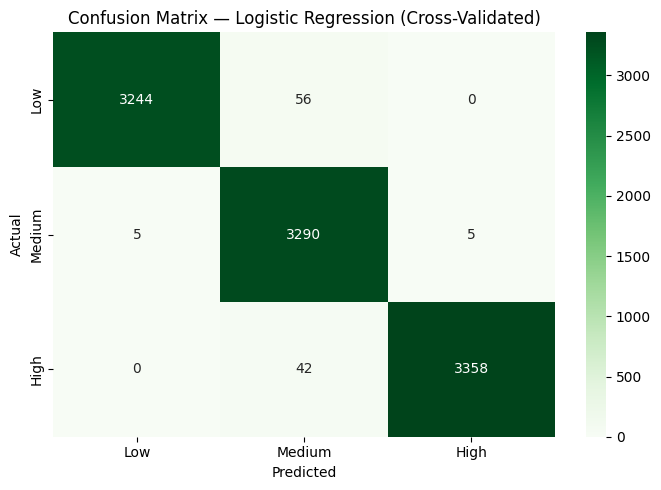

In [33]:
cm_lr = confusion_matrix(y_model, y_pred_lr)
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_lr, annot=True, fmt='d', cmap='Greens',
    xticklabels=['Low', 'Medium', 'High'],
    yticklabels=['Low', 'Medium', 'High']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Logistic Regression (Cross-Validated)')
plt.tight_layout()
plt.show()

### 8.3 ROC AUC Curve — Logistic Regression

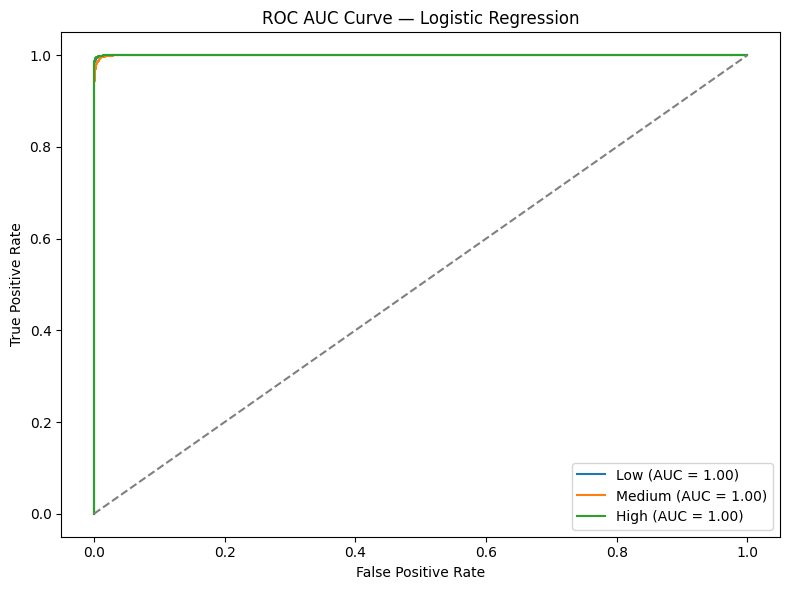

In [34]:
y_prob_lr = cross_val_predict(logreg_model, X_model, y_model, cv=kf, method='predict_proba')

plt.figure(figsize=(8, 6))
for i, name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob_lr[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC AUC Curve — Logistic Regression')
plt.legend()
plt.tight_layout()
plt.show()

## 9. Perbandingan Model — Naive Bayes vs Logistic Regression

Bagian ini membandingkan kedua model supervised learning secara langsung menggunakan metrik yang sama (akurasi rata-rata K-Fold, standar deviasi, dan F1-score makro).

In [35]:
from sklearn.metrics import f1_score

f1_nb = f1_score(y_model, y_pred_cv, average='macro')
f1_lr = f1_score(y_model, y_pred_lr, average='macro')

comparison = pd.DataFrame({
    'Model': ['Naive Bayes', 'Logistic Regression'],
    'Mean Accuracy (CV)': [cv_scores.mean(), cv_scores_lr.mean()],
    'Std Accuracy (CV)': [cv_scores.std(), cv_scores_lr.std()],
    'Macro F1-Score': [f1_nb, f1_lr]
})

comparison_display = comparison.copy()
comparison_display['Mean Accuracy (CV)'] = comparison_display['Mean Accuracy (CV)'].map(lambda x: f'{x:.4f}')
comparison_display['Std Accuracy (CV)'] = comparison_display['Std Accuracy (CV)'].map(lambda x: f'{x:.4f}')
comparison_display['Macro F1-Score'] = comparison_display['Macro F1-Score'].map(lambda x: f'{x:.4f}')
comparison_display

,Model,Mean Accuracy (CV),Std Accuracy (CV),Macro F1-Score
0,Naive Bayes,0.8475,0.0073,0.8498
1,Logistic Regression,0.9892,0.0023,0.9892


**Interpretasi perbandingan model**
Berdasarkan perbandingan antara Naive Bayes dan Logistic Regression, Logistic Regression 
menghasilkan akurasi rata-rata (98.9%) dan F1-score (0.99) yang jauh lebih tinggi 
dibandingkan Naive Bayes (84.7% dan 0.85). Selisih ini cukup besar dan dapat dijelaskan 
dari karakteristik data: `overall_score` (dasar pembentukan Performance_Category) 
merupakan kombinasi/agregasi dari beberapa fitur seperti final_exam_score, midterm_score, 
dan assignment_score. Logistic Regression dapat menangkap hubungan linear semacam ini 
dengan baik, sementara Naive Bayes mengasumsikan independensi antar fitur terhadap kelas 
target — asumsi yang kurang sesuai karena beberapa fitur saling berkontribusi secara 
aditif dalam membentuk skor akhir siswa.

Logistic Regression juga menunjukkan standar deviasi akurasi yang lebih kecil antar fold 
(0.0022 dibanding 0.0073 pada Naive Bayes), menunjukkan performa yang lebih konsisten dan 
stabil pada berbagai pembagian data.

Berdasarkan hasil ini, Logistic Regression direkomendasikan sebagai model utama untuk 
digunakan dalam dashboard/deployment, dengan Naive Bayes sebagai pembanding karena 
keunggulannya dalam kecepatan komputasi dan kesederhanaan model.

In [36]:
import pickle
import joblib

logreg_model.fit(X_model, y_model)

with open('logreg_model.pkl', 'wb') as f:
    pickle.dump(logreg_model, f)

joblib.dump(mm_scaler, 'mm_scaler.pkl')
joblib.dump(X_model.columns.tolist(), 'model_columns.pkl')

# Simpan q33 dan q66 juga
joblib.dump({'q33': q33, 'q66': q66}, 'thresholds.pkl')

print("Tersimpan: logreg_model.pkl, mm_scaler.pkl, model_columns.pkl, thresholds.pkl")

Tersimpan: logreg_model.pkl, mm_scaler.pkl, model_columns.pkl, thresholds.pkl


## Kesimpulan

| Tahap | Hasil |
|-------|-------|
| **Preprocessing** | Data bersih (tidak ada missing value/duplikasi), encoding terpusat (One-Hot), scaling terpisah untuk clustering (MinMax) dan PCA (Standard) |
| **PCA** | Varians terdistribusi merata antar komponen (~16-17% tiap PC) — mengindikasikan fitur-fitur akademik relatif independen satu sama lain |
| **Clustering (KMeans)** | Silhouette score rendah (0.11-0.13) di semua k, didukung pairplot yang menunjukkan distribusi uniform tanpa blob terpisah, serta ARI/NMI yang rendah terhadap Performance_Category. **Kesimpulan: dataset ini tidak memiliki struktur cluster natural yang bermakna pada level fitur akademik mentah.** |
| **Klasifikasi (Naive Bayes + K-Fold)** | Akurasi ~84.7% |
| **Klasifikasi (Logistic Regression + K-Fold)** | Akurasi rata-rata 98.9% lebih tinggi dari pada klasifikasi naive bayes |


## 10. Dashboard

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import pickle
import joblib
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_curve, auc, confusion_matrix
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns

# ── Load artifacts ────────────────────────────────────────────────
with open('logreg_model.pkl', 'rb') as f:
    model = pickle.load(f)

mm_scaler    = joblib.load('mm_scaler.pkl')
model_cols   = joblib.load('model_columns.pkl')

# ── Konstanta (harus konsisten dengan notebook) ───────────────────
NUM_COLS = [
    'study_hours_per_day', 'attendance_percentage', 'assignment_score',
    'midterm_score', 'final_exam_score', 'participation_score', 'sleep_hours'
]
TARGET_COL   = 'Performance_Category'
DROP_FOR_MODEL = ['overall_score', 'grade', TARGET_COL]
BINARY_COLS  = ['gender', 'internet_access', 'extra_classes']
NOMINAL_COLS = ['parent_education']
CLASS_NAMES  = ['Low', 'Medium', 'High']

# ── Identitas kelompok ────────────────────────────────────
KELOMPOK = "Kelompok 3"
KELAS    = "SI-48-01"
PRODI    = "S1 Sistem Informasi"
KAMPUS   = "Universitas Telkom"
ANGGOTA  = [
    {"nama": "Malky Sudrajat Asshidiq", "nim": "102022400204"},
    {"nama": "Sitti Naurah bauw", "nim": "102022430071"},
    {"nama": "Mia Stacia Adelia Effendi", "nim": "102022400134"},
]

# ── Label fitur agar mudah dibaca pada narasi ─────────────
FEATURE_LABELS = {
    'study_hours_per_day':   'jam belajar per hari',
    'attendance_percentage': 'persentase kehadiran',
    'assignment_score':      'nilai tugas',
    'midterm_score':         'nilai UTS',
    'final_exam_score':      'nilai UAS',
    'participation_score':   'nilai partisipasi',
    'sleep_hours':           'jam tidur per hari',
    'gender_Male':           'jenis kelamin laki-laki',
    'gender_Female':         'jenis kelamin perempuan',
    'internet_access_Yes':   'memiliki akses internet',
    'internet_access_No':    'tidak memiliki akses internet',
    'extra_classes_Yes':     'mengikuti kelas tambahan',
    'extra_classes_No':      'tidak mengikuti kelas tambahan',
    'parent_education_High School': 'pendidikan orang tua (SMA)',
    'parent_education_Bachelor':    'pendidikan orang tua (S1)',
    'parent_education_Master':      'pendidikan orang tua (S2)',
    'parent_education_PhD':         'pendidikan orang tua (S3)',
}

# ── Load & prep data untuk metrik evaluasi ────────────────────────
@st.cache_data
def load_eval_data():
    df_raw = pd.read_csv('student_performance_data.csv')
    df = df_raw.drop(columns=['student_id'])

    # Outlier handling (IQR) — sama persis dengan notebook
    df_clean = df.copy()
    for col in NUM_COLS:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        df_clean = df_clean[
            (df_clean[col] >= Q1 - 1.5 * IQR) &
            (df_clean[col] <= Q3 + 1.5 * IQR)
        ]
    df = df_clean.reset_index(drop=True)

    # Binning — quantile sama dengan notebook
    q33 = df['overall_score'].quantile(0.33)
    q66 = df['overall_score'].quantile(0.66)
    df[TARGET_COL] = pd.cut(
        df['overall_score'],
        bins=[-np.inf, q33, q66, np.inf],
        labels=[0, 1, 2]
    ).astype(int)

    # Encoding
    df_encoded = pd.get_dummies(df, columns=BINARY_COLS + NOMINAL_COLS, drop_first=False)
    df_encoded[NUM_COLS] = mm_scaler.transform(df_encoded[NUM_COLS])

    drop_cols = [col for col in DROP_FOR_MODEL + ['grade'] if col in df_encoded.columns]
    X = df_encoded.drop(columns=drop_cols)
    X = X.astype({col: int for col in X.select_dtypes(include='bool').columns})
    X = X.reindex(columns=model_cols, fill_value=0)
    y = df_encoded[TARGET_COL]

    return X, y


# ── Fungsi pembuat narasi penjelasan prediksi ─────────────
def buat_narasi(pred_label, proba, raw_vals, coef_df):
    """Menghasilkan paragraf naratif yang menjelaskan alasan di balik prediksi."""

    def level_skor(v):
        if v >= 70: return "tergolong tinggi"
        if v >= 55: return "berada pada kisaran sedang"
        return "tergolong rendah"

    def level_jam_belajar(v):
        if v >= 7: return "cukup intens"
        if v >= 4: return "cukup memadai"
        return "tergolong rendah"

    def level_hadir(v):
        if v >= 80: return "tergolong tinggi"
        if v >= 60: return "berada pada kisaran sedang"
        return "tergolong rendah"

    tugas   = raw_vals['assignment_score']
    uts     = raw_vals['midterm_score']
    uas     = raw_vals['final_exam_score']
    partisi = raw_vals['participation_score']
    jam     = raw_vals['study_hours_per_day']
    hadir   = raw_vals['attendance_percentage']

    rata_akademik = np.mean([tugas, uts, uas, partisi])
    if rata_akademik >= 70:
        ringkas_akademik = "secara umum tergolong tinggi"
    elif rata_akademik >= 55:
        ringkas_akademik = "secara umum berada pada kisaran menengah"
    else:
        ringkas_akademik = "secara umum tergolong rendah"

    # Tiga faktor model paling berpengaruh, diterjemahkan ke bahasa yang mudah dibaca
    faktor_utama = []
    for fitur in coef_df['Fitur'].head(3):
        faktor_utama.append(FEATURE_LABELS.get(fitur, fitur))
    faktor_str = ", ".join(faktor_utama)

    # Paragraf 1 — keputusan, keyakinan, dan profil akademik
    p1 = (
        f"Model memprediksi siswa ini termasuk dalam kategori performa **{pred_label}** "
        f"dengan tingkat keyakinan sebesar {proba:.1%}. Prediksi tersebut terutama "
        f"didasarkan pada profil nilai akademik siswa, yaitu nilai tugas sebesar {tugas:.0f} "
        f"({level_skor(tugas)}), nilai UTS sebesar {uts:.0f} ({level_skor(uts)}), "
        f"nilai UAS sebesar {uas:.0f} ({level_skor(uas)}), serta nilai partisipasi sebesar "
        f"{partisi:.0f} ({level_skor(partisi)}). Jika dilihat secara keseluruhan, capaian "
        f"akademik siswa ini {ringkas_akademik}."
    )

    # Paragraf 2 — faktor pendukung + faktor dominan model
    p2 = (
        f"Selain capaian akademik, faktor pendukung lain turut diperhitungkan, antara lain "
        f"jam belajar sebesar {jam:.1f} jam per hari ({level_jam_belajar(jam)}) dan tingkat "
        f"kehadiran sebesar {hadir:.0f}% ({level_hadir(hadir)}). Berdasarkan analisis kontribusi "
        f"model, faktor yang paling mendorong siswa diklasifikasikan ke kategori {pred_label} "
        f"adalah {faktor_str}. Hal ini sejalan dengan logika data, karena kategori performa pada "
        f"dasarnya terbentuk dari akumulasi nilai-nilai akademik tersebut."
    )

    # Paragraf 3 — penutup sesuai kategori
    if pred_label == "High":
        p3 = ("Kombinasi capaian yang baik pada sebagian besar aspek inilah yang membuat siswa "
              "diprediksi memiliki performa tinggi.")
    elif pred_label == "Medium":
        p3 = ("Capaian yang berada pada kisaran menengah dan belum konsisten menonjol di seluruh "
              "aspek membuat siswa diprediksi memiliki performa sedang.")
    else:
        p3 = ("Capaian yang relatif rendah pada beberapa aspek membuat siswa diprediksi berisiko "
              "memiliki performa rendah, sehingga dapat menjadi perhatian pihak akademik untuk "
              "pendampingan atau intervensi lebih lanjut.")

    return p1, p2, p3


X_eval, y_eval = load_eval_data()

y_pred_eval = model.predict(X_eval)
y_prob_eval = model.predict_proba(X_eval)

acc  = accuracy_score(y_eval, y_pred_eval)
prec = precision_score(y_eval, y_pred_eval, average='weighted')
rec  = recall_score(y_eval, y_pred_eval, average='weighted')
y_bin = label_binarize(y_eval, classes=[0, 1, 2])

# ── Sidebar identitas kelompok ────────────────────────────
with st.sidebar:
    st.header("Identitas Kelompok")
    st.markdown(f"**{KELOMPOK}**")
    st.markdown(f"Kelas: **{KELAS}**")
    st.markdown(f"{PRODI} — {KAMPUS}")
    st.divider()
    st.subheader("Anggota Kelompok")
    for i, a in enumerate(ANGGOTA, 1):
        st.markdown(f"{i}. **{a['nama']}** — {a['nim']}")

# ── Layout ────────────────────────────────────────────────────────
st.title("Student Performance Prediction")
st.markdown("Prediksi kategori performa siswa menggunakan Logistic Regression.")
st.divider()

# ── Metrik evaluasi ───────────────────────────────────────────────
st.subheader("Evaluasi Model")
col1, col2, col3 = st.columns(3)
col1.metric("Accuracy",  f"{acc:.2f}")
col2.metric("Precision", f"{prec:.2f}")
col3.metric("Recall",    f"{rec:.2f}")

# ── Visualisasi ───────────────────────────────────────────────────
st.subheader("Visualisasi")
chart_option = st.selectbox("Pilih grafik:", ["ROC AUC Curve", "Confusion Matrix"])

if chart_option == "ROC AUC Curve":
    fig, ax = plt.subplots(figsize=(7, 5))
    for i, name in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob_eval[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')
    ax.plot([0, 1], [0, 1], '--', color='gray')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC AUC Curve — Logistic Regression')
    ax.legend()
    st.pyplot(fig)
else:
    cm = confusion_matrix(y_eval, y_pred_eval)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title('Confusion Matrix — Logistic Regression')
    st.pyplot(fig)

st.divider()

# ── Form prediksi ─────────────────────────────────────────────────
st.subheader("Prediksi Performa Siswa")
st.markdown("Masukkan data siswa sesuai nilai aslinya (sebelum normalisasi).")

with st.form("form_prediksi"):
    col1, col2 = st.columns(2)

    with col1:
        gender          = st.selectbox("Gender", ["Male", "Female"])
        study_hours     = st.number_input("Jam Belajar per Hari", min_value=0.0, max_value=24.0, step=0.5, value=6.0)
        attendance      = st.number_input("Attendance (%)", min_value=0.0, max_value=100.0, step=1.0, value=80.0)
        assignment      = st.number_input("Assignment Score (0-100)", min_value=0.0, max_value=100.0, step=1.0, value=70.0)
        midterm         = st.number_input("Midterm Score (0-100)", min_value=0.0, max_value=100.0, step=1.0, value=70.0)

    with col2:
        final_exam      = st.number_input("Final Exam Score (0-100)", min_value=0.0, max_value=100.0, step=1.0, value=70.0)
        participation   = st.number_input("Participation Score (0-100)", min_value=0.0, max_value=100.0, step=1.0, value=70.0)
        sleep_hours     = st.number_input("Jam Tidur per Hari", min_value=0.0, max_value=24.0, step=0.5, value=7.0)
        internet_access = st.selectbox("Internet Access", ["Yes", "No"])
        extra_classes   = st.selectbox("Extra Classes", ["Yes", "No"])
        parent_edu      = st.selectbox("Parent Education", ["High School", "Bachelor", "Master", "PhD"])

    submit = st.form_submit_button("Prediksi")

if submit:
    # ── Simpan nilai asli (sebelum normalisasi) untuk narasi
    raw_vals = {
        'study_hours_per_day':   study_hours,
        'attendance_percentage': attendance,
        'assignment_score':      assignment,
        'midterm_score':         midterm,
        'final_exam_score':      final_exam,
        'participation_score':   participation,
        'sleep_hours':           sleep_hours,
    }

    # Buat dataframe input dalam skala asli
    input_raw = pd.DataFrame([{
        'study_hours_per_day':   study_hours,
        'attendance_percentage': attendance,
        'assignment_score':      assignment,
        'midterm_score':         midterm,
        'final_exam_score':      final_exam,
        'participation_score':   participation,
        'sleep_hours':           sleep_hours,
        'gender':                gender,
        'internet_access':       internet_access,
        'extra_classes':         extra_classes,
        'parent_education':      parent_edu
    }])

    # Normalisasi NUM_COLS pakai scaler yang sama
    input_raw[NUM_COLS] = mm_scaler.transform(input_raw[NUM_COLS])

    # One-hot encoding
    input_encoded = pd.get_dummies(input_raw, columns=BINARY_COLS + NOMINAL_COLS, drop_first=False)

    # Align kolom dengan model
    input_aligned = input_encoded.reindex(columns=model_cols, fill_value=0)
    input_aligned = input_aligned.astype({
        col: int for col in input_aligned.select_dtypes(include='bool').columns
    })

    # Prediksi
    pred       = model.predict(input_aligned)[0]
    pred_proba = model.predict_proba(input_aligned)[0]
    pred_label = CLASS_NAMES[pred]

    # Tampilkan hasil
    st.success(f"Prediksi Kategori Performa: **{pred_label}**")

    st.subheader("Probabilitas per Kategori")
    proba_df = pd.DataFrame({
        'Kategori':    CLASS_NAMES,
        'Probabilitas': pred_proba
    }).sort_values('Probabilitas', ascending=False)

    fig, ax = plt.subplots(figsize=(6, 3))
    colors = ['#2196F3' if c == pred_label else '#B0BEC5' for c in proba_df['Kategori']]
    ax.barh(proba_df['Kategori'], proba_df['Probabilitas'], color=colors)
    ax.set_xlabel('Probabilitas')
    ax.set_xlim(0, 1)
    ax.set_title('Distribusi Probabilitas Prediksi')
    for i, (val, cat) in enumerate(zip(proba_df['Probabilitas'], proba_df['Kategori'])):
        ax.text(val + 0.01, i, f'{val:.1%}', va='center')
    st.pyplot(fig)

    # Hitung kontribusi fitur
    coef_df = pd.DataFrame({
        'Fitur':       model_cols,
        'Koefisien':   model.coef_[pred]
    }).reindex(columns=['Fitur', 'Koefisien'])

    input_vals = input_aligned.iloc[0]
    coef_df['Kontribusi'] = coef_df['Koefisien'] * input_vals.values
    coef_df = coef_df.reindex(columns=['Fitur', 'Koefisien', 'Kontribusi'])
    coef_df = coef_df.sort_values('Kontribusi', ascending=False).head(5)

    # ── Narasi penjelasan prediksi ───────────────────────
    st.subheader("Penjelasan Hasil Prediksi")
    p1, p2, p3 = buat_narasi(pred_label, pred_proba[pred], raw_vals, coef_df)
    st.markdown(p1)
    st.markdown(p2)
    st.markdown(p3)

    # Tabel faktor (tetap dipertahankan sebagai pelengkap)
    st.subheader("Faktor yang Mempengaruhi Prediksi")
    st.markdown(f"**5 fitur dengan kontribusi terbesar ke kelas '{pred_label}':**")
    st.dataframe(coef_df.reset_index(drop=True), use_container_width=True)

Overwriting app.py


t=2026-06-21T14:51:43+0700 lvl=warn msg="failed to open private leg" id=8615c09152ca privaddr=localhost:8501 err="dial tcp [::1]:8501: connectex: No connection could be made because the target machine actively refused it."
t=2026-06-21T14:51:43+0700 lvl=warn msg="failed to open private leg" id=7bc667b92924 privaddr=localhost:8501 err="dial tcp [::1]:8501: connectex: No connection could be made because the target machine actively refused it."
t=2026-06-21T14:51:46+0700 lvl=warn msg="failed to open private leg" id=ea0ce8fc36f7 privaddr=localhost:8501 err="dial tcp [::1]:8501: connectex: No connection could be made because the target machine actively refused it."
t=2026-06-21T14:51:46+0700 lvl=warn msg="failed to open private leg" id=c2cd6d057c4b privaddr=localhost:8501 err="dial tcp [::1]:8501: connectex: No connection could be made because the target machine actively refused it."


In [45]:
!ngrok config add-authtoken 3DqluvEixdep6aN2E5IHVhXOiUq_7VqC3eUQrao1qLLj5WdG9

t=2026-06-21T14:51:49+0700 lvl=warn msg="failed to open private leg" id=23515c772ac2 privaddr=localhost:8501 err="dial tcp [::1]:8501: connectex: No connection could be made because the target machine actively refused it."
t=2026-06-21T14:51:49+0700 lvl=warn msg="failed to open private leg" id=40e32d72fb3c privaddr=localhost:8501 err="dial tcp [::1]:8501: connectex: No connection could be made because the target machine actively refused it."


Authtoken saved to configuration file: C:\Users\lenovo\AppData\Local\ngrok\ngrok.yml


In [ ]:
from pyngrok import ngrok
import threading
import time
import os
import sys

def run_streamlit():
    os.system(f'"{sys.executable}" -m streamlit run app.py --server.port 8501 --server.headless true')
    
ngrok.kill()

thread = threading.Thread(target=run_streamlit, daemon=True)
thread.start()
time.sleep(8)

public_url = ngrok.connect(8501, "http").public_url
print(f"App is live at: {public_url}")

App is live at: https://tray-scalding-tremor.ngrok-free.dev


t=2026-06-21T20:52:04+0700 lvl=warn msg="failed to check for update" obj=updater err="Post \"https://update.ngrok-agent.com/check\": context deadline exceeded"
